✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Main contour area: 708012 px
Kept: 1565 inside, 553 near edge/bottom


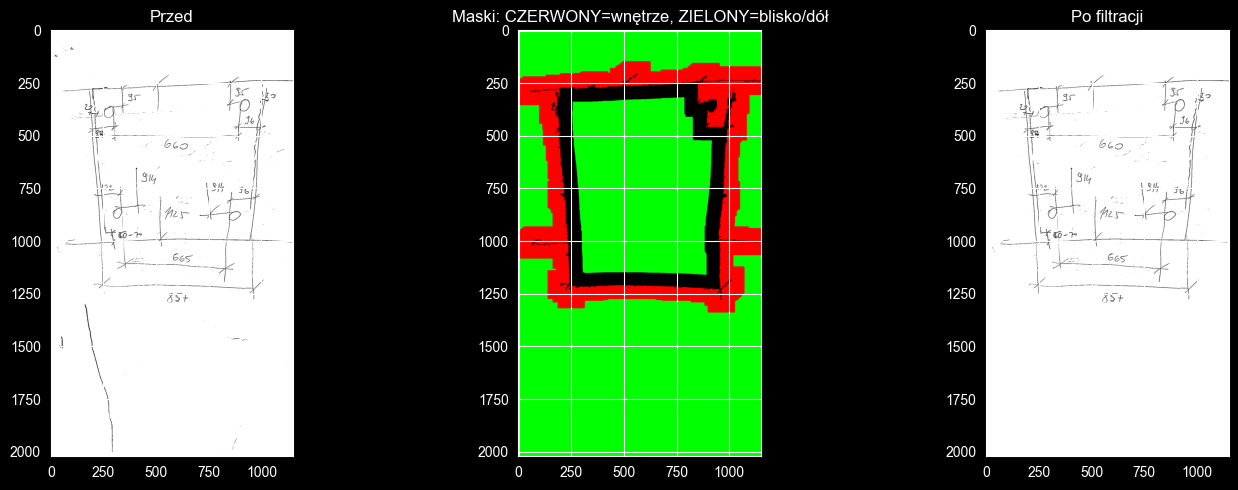

LSD detected: 486 lines
Before merge: 486
After overlap-based merge: 226 lines
Main rectangle found: 1096 x 1072 px, area=708012

After main rectangle extraction:
  Horizontal: 8 (including 4 from main rect)
  Vertical: 0

Classification by angle:
  Horizontal:       30
  Vertical:         38
  Diagonal 45° (+): 2
  Diagonal 45° (-): 52
  Diagonal other:   104

Endpoint graph:
  Nodes: 293
  Edges: 226
  Intersections (degree>2): 29

Manual dimensions: {'width_mm': 857, 'height_mm': 1125, 'hole_position_mm': 914, 'small_dimensions_mm': [95, 102], 'range_mm': '60-70'}


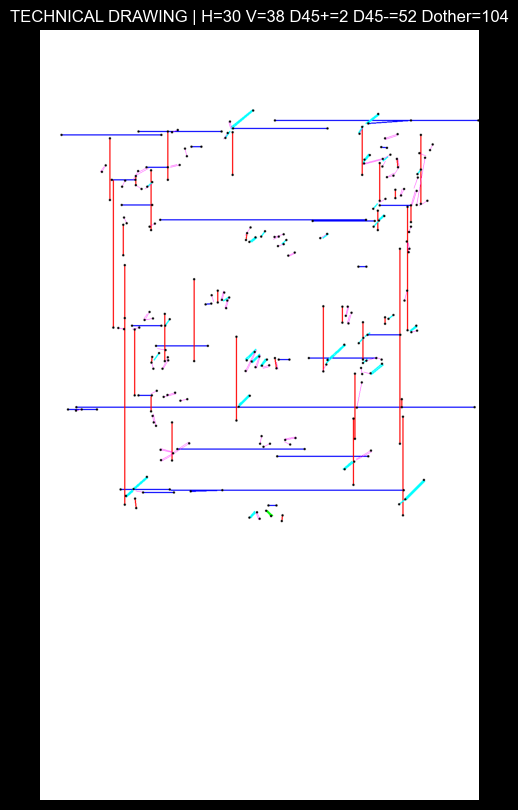


✅ VERTICAL SLICE DONE
   JSON: C:\python\Intelligent_Sketch2CAD\intermediate_data\technical_drawing_20260510_225833.json
   Image: C:\python\Intelligent_Sketch2CAD\intermediate_data\technical_drawing_20260510_225833.jpg

   Statistics:
     Horizontal: 30
     Vertical: 38
     Diagonal 45°+: 2
     Diagonal 45°-: 52
     Diagonal other: 104

   Endpoint graph: 293 nodes, 226 edges

   Dimensions for CAD: 857 x 1125 mm

▶ Next: Import JSON to FreeCAD


In [14]:
# -------------------------------
# VERTICAL SLICE: SKETCH → TECHNICAL DRAWING
# with 5-angle classification + endpoint graph
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime
from collections import defaultdict

print("✓ Ready")

# -------------------------------
# PATHS
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------
# LOAD LATEST IMAGE
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
if len(image.shape) == 3:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
else:
    gray = image

# Fix polarity (white background, black lines)
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed")
################################
# -------------------------------
# Poprawione filtrowanie komponentów – dodatkowo zachowaj wszystko w dolnym pasie
# -------------------------------
# Wejście: gray (binarny, biały background, czarne linie)

contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("No contours found – keeping original")
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    area_main = cv2.contourArea(main_contour)
    print(f"Main contour area: {area_main:.0f} px")

    # Maska wewnątrz
    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)

    # Maska "blisko krawędzi" – większy obszar (120 px)
    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    kernel_large = np.ones((120, 120), np.uint8)
    mask_near = cv2.dilate(mask_edge, kernel_large, iterations=1)

    # Używaj tylko maski blisko krawędzi (bez sztucznego dolnego pasa)
    mask_near_or_bottom = mask_near

    # Teraz connected components
    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)

    mask_final = np.zeros_like(gray, dtype=np.uint8)
    MAX_AREA_SMALL = 1500  # nieco większe, by chwycić cyfry

    kept_inside = 0
    kept_near = 0

    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]

        # Wewnątrz – zawsze zachowaj
        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
            kept_inside += 1
            continue

        # Blisko krawędzi lub w dolnym pasie – zachowaj jeśli mały
        in_near = cv2.bitwise_and(comp_mask, mask_near_or_bottom)
        if in_near.any() and area < MAX_AREA_SMALL:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
            kept_near += 1
            continue

    print(f"Kept: {kept_inside} inside, {kept_near} near edge/bottom")

    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255

    # Wizualizacja
    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Przed")
    plt.subplot(1,3,2)
    # Pokaż maski: czerwony = wnętrze, zielony = blisko + dolny pas
    viz = np.zeros((*gray.shape, 3), dtype=np.uint8)
    viz[mask_inside==0] = [255,0,0]

    viz[mask_near_or_bottom == 0] = [0,255,0]
    plt.imshow(viz)
    plt.title("Maski: CZERWONY=wnętrze, ZIELONY=blisko/dół")
    plt.subplot(1,3,3); plt.imshow(gray_filtered, cmap='gray'); plt.title("Po filtracji")
    plt.tight_layout()
    plt.show()

    gray = gray_filtered
# -------------------------------
# LSD DETECTION
# -------------------------------
lsd = cv2.createLineSegmentDetector(0)
lines_raw = lsd.detect(gray)[0]

all_lines = []
if lines_raw is not None:
    for line in lines_raw:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        if length >= 15:
            all_lines.append([int(x1), int(y1), int(x2), int(y2)])

print(f"LSD detected: {len(all_lines)} lines")

# -------------------------------
# MERGE COLLINEAR SEGMENTS (overlap-based, not bbox)
# -------------------------------
def merge_collinear_overlap(lines, angle_threshold=10, distance_threshold=25, overlap_ratio=0.3):
    """
    Łączy segmenty które są współliniowe i mają overlapping lub małą przerwę.
    Dla poziomych: sprawdza Y + overlapping w X
    Dla pionowych: sprawdza X + overlapping w Y
    """
    if len(lines) < 2:
        return lines

    # Najpierw klasyfikacja wstępna
    horizontal = []
    vertical = []
    diagonal = []

    for line in lines:
        x1, y1, x2, y2 = line
        dx = x2 - x1
        dy = y2 - y1
        angle = np.degrees(np.arctan2(dy, dx)) % 180

        if angle < 10 or angle > 170:
            horizontal.append(line)
        elif abs(angle - 90) < 10:
            vertical.append(line)
        else:
            diagonal.append(line)

    def merge_group(group, is_horizontal):
        if len(group) < 2:
            return group

        # Sortuj
        if is_horizontal:
            group.sort(key=lambda l: (l[1] + l[3]) // 2)  # po Y
        else:
            group.sort(key=lambda l: (l[0] + l[2]) // 2)  # po X

        merged = []
        used = [False] * len(group)

        for i, line1 in enumerate(group):
            if used[i]:
                continue

            current = line1.copy()
            used[i] = True

            for j, line2 in enumerate(group):
                if used[j]:
                    continue

                if is_horizontal:
                    # Poziome: podobne Y
                    y1 = (current[1] + current[3]) // 2
                    y2 = (line2[1] + line2[3]) // 2
                    if abs(y1 - y2) > distance_threshold:
                        continue

                    # Sprawdź overlapping w X
                    x1_start, x1_end = sorted([current[0], current[2]])
                    x2_start, x2_end = sorted([line2[0], line2[2]])

                    overlap = max(0, min(x1_end, x2_end) - max(x1_start, x2_start))
                    len1 = x1_end - x1_start
                    len2 = x2_end - x2_start

                    if overlap > 0 and overlap / min(len1, len2) > overlap_ratio:
                        # Overlap - rozszerz
                        current = [min(x1_start, x2_start), y1, max(x1_end, x2_end), y1]
                        used[j] = True
                    elif abs(x1_end - x2_start) < distance_threshold or abs(x2_end - x1_start) < distance_threshold:
                        # Mała przerwa - połącz
                        current = [min(x1_start, x2_start), y1, max(x1_end, x2_end), y1]
                        used[j] = True

                else:  # vertical
                    # Pionowe: podobne X
                    x1 = (current[0] + current[2]) // 2
                    x2 = (line2[0] + line2[2]) // 2
                    if abs(x1 - x2) > distance_threshold:
                        continue

                    # Sprawdź overlapping w Y
                    y1_start, y1_end = sorted([current[1], current[3]])
                    y2_start, y2_end = sorted([line2[1], line2[3]])

                    overlap = max(0, min(y1_end, y2_end) - max(y1_start, y2_start))
                    len1 = y1_end - y1_start
                    len2 = y2_end - y2_start

                    if overlap > 0 and overlap / min(len1, len2) > overlap_ratio:
                        current = [x1, min(y1_start, y2_start), x1, max(y1_end, y2_end)]
                        used[j] = True
                    elif abs(y1_end - y2_start) < distance_threshold or abs(y2_end - y1_start) < distance_threshold:
                        current = [x1, min(y1_start, y2_start), x1, max(y1_end, y2_end)]
                        used[j] = True

            merged.append(current)

        return merged

    # Scal osobno dla każdej grupy
    horizontal = merge_group(horizontal, True)
    vertical = merge_group(vertical, False)

    # Diagonalne zostawiamy bez scalania (na razie)
    merged_lines = horizontal + vertical + diagonal

    print(f"After overlap-based merge: {len(merged_lines)} lines")
    return merged_lines

print(f"Before merge: {len(all_lines)}")
all_lines = merge_collinear_overlap(all_lines, angle_threshold=10, distance_threshold=25, overlap_ratio=0.3)
###############################################
# -------------------------------
# EXTRACT MAIN RECTANGLE FROM CONTOURS
# -------------------------------
# Znajdź największy kontur (główny obiekt)
contour_img = cv2.bitwise_not(gray)  # odwróć (czarne tło, białe linie do findContours)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Największy kontur = główny prostokąt
    main_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(main_contour)
    x, y, w, h = cv2.boundingRect(main_contour)

    print(f"Main rectangle found: {w} x {h} px, area={area:.0f}")

    # Stwórz listę linii TYLKO z głównego prostokąta
    main_lines = []
    main_lines.append([x, y, x+w, y])      # top
    main_lines.append([x, y+h, x+w, y+h])  # bottom
    main_lines.append([x, y, x, y+h])      # left
    main_lines.append([x+w, y, x+w, y+h])  # right

    # Odfiltruj szum: zachowaj tylko linie które są blisko głównego prostokąta
    # lub są długimi liniami poziomymi/pionowymi
    filtered_horizontal = []
    filtered_vertical = []
    filtered_diag_pos = []
    filtered_diag_neg = []
    filtered_diag_other = []

    # Tolerancja odległości od głównego prostokąta
    margin = 50

    for line in horizontal:
        # Sprawdź czy linia jest blisko głównego prostokąta
        _, y1, _, y2 = line
        if abs(y1 - y) < margin or abs(y1 - (y+h)) < margin:
            filtered_horizontal.append(line)
        elif abs(y2 - y) < margin or abs(y2 - (y+h)) < margin:
            filtered_horizontal.append(line)
        else:
            # Długie linie poziome (montażowe)
            length = np.hypot(line[2]-line[0], line[3]-line[1])
            if length > w * 0.7:
                filtered_horizontal.append(line)

    for line in vertical:
        x1, _, x2, _ = line
        if abs(x1 - x) < margin or abs(x1 - (x+w)) < margin:
            filtered_vertical.append(line)
        elif abs(x2 - x) < margin or abs(x2 - (x+w)) < margin:
            filtered_vertical.append(line)
        else:
            length = np.hypot(line[2]-line[0], line[3]-line[1])
            if length > h * 0.7:
                filtered_vertical.append(line)

    # Dla diagonalnych (ticki) - zachowaj wszystkie (są przy wymiarach)
    filtered_diag_pos = diagonal_45_pos
    filtered_diag_neg = diagonal_45_neg
    filtered_diag_other = diagonal_other

    # Zastąp oryginalne listy
    horizontal = main_lines + filtered_horizontal
    vertical = filtered_vertical
    diagonal_45_pos = filtered_diag_pos
    diagonal_45_neg = filtered_diag_neg
    diagonal_other = filtered_diag_other

    print(f"\nAfter main rectangle extraction:")
    print(f"  Horizontal: {len(horizontal)} (including 4 from main rect)")
    print(f"  Vertical: {len(vertical)}")

else:
    print("No main contour found - using all lines")
# -------------------------------
# CLASSIFY BY ANGLE (5 categories)
# -------------------------------
def classify_line_angle(line):
    x1, y1, x2, y2 = line
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180

    if angle < 10 or angle > 170:
        return "horizontal"
    elif 80 < angle < 100:
        return "vertical"
    elif 35 < angle < 55:
        return "diagonal_45_pos"
    elif 125 < angle < 145:
        return "diagonal_45_neg"
    else:
        return "diagonal_other"

# Klasyfikacja
horizontal = []
vertical = []
diagonal_45_pos = []
diagonal_45_neg = []
diagonal_other = []

for line in all_lines:
    cat = classify_line_angle(line)
    if cat == "horizontal":
        horizontal.append(line)
    elif cat == "vertical":
        vertical.append(line)
    elif cat == "diagonal_45_pos":
        diagonal_45_pos.append(line)
    elif cat == "diagonal_45_neg":
        diagonal_45_neg.append(line)
    else:
        diagonal_other.append(line)

print(f"\nClassification by angle:")
print(f"  Horizontal:       {len(horizontal)}")
print(f"  Vertical:         {len(vertical)}")
print(f"  Diagonal 45° (+): {len(diagonal_45_pos)}")
print(f"  Diagonal 45° (-): {len(diagonal_45_neg)}")
print(f"  Diagonal other:   {len(diagonal_other)}")

# -------------------------------
# ENDPOINT GRAPH (for future geometry reconstruction)
# -------------------------------
def build_endpoint_graph(lines):
    """
    Buduje graf wierzchołków:
    - każdy koniec linii to node
    - linia to edge między dwoma node'ami
    - znajduje przecięcia (node'y które są blisko siebie)
    """
    nodes = []  # lista (x, y)
    edges = []  # lista (node_idx1, node_idx2, line_idx)

    # Tolerancja dla łączenia bliskich punktów
    proximity_threshold = 8  # pikseli

    for line_idx, line in enumerate(lines):
        x1, y1, x2, y2 = line

        # Znajdź lub dodaj node dla (x1, y1)
        node1_idx = None
        for i, (nx, ny) in enumerate(nodes):
            if abs(nx - x1) < proximity_threshold and abs(ny - y1) < proximity_threshold:
                node1_idx = i
                break
        if node1_idx is None:
            node1_idx = len(nodes)
            nodes.append((x1, y1))

        # Znajdź lub dodaj node dla (x2, y2)
        node2_idx = None
        for i, (nx, ny) in enumerate(nodes):
            if abs(nx - x2) < proximity_threshold and abs(ny - y2) < proximity_threshold:
                node2_idx = i
                break
        if node2_idx is None:
            node2_idx = len(nodes)
            nodes.append((x2, y2))

        edges.append((node1_idx, node2_idx, line_idx))

    # Znajdź przecięcia (node'y gdzie schodzi się >2 linie)
    node_degree = defaultdict(int)
    for e in edges:
        node_degree[e[0]] += 1
        node_degree[e[1]] += 1

    intersections = [i for i, deg in node_degree.items() if deg > 2]

    print(f"\nEndpoint graph:")
    print(f"  Nodes: {len(nodes)}")
    print(f"  Edges: {len(edges)}")
    print(f"  Intersections (degree>2): {len(intersections)}")

    return {
        "nodes": nodes,
        "edges": edges,
        "intersections": intersections,
        "node_degree": dict(node_degree)
    }

graph = build_endpoint_graph(all_lines)

# -------------------------------
# MANUAL DIMENSIONS (from your drawing)
# -------------------------------
dimensions = {
    "width_mm": 857,
    "height_mm": 1125,
    "hole_position_mm": 914,
    "small_dimensions_mm": [95, 102],
    "range_mm": "60-70"
}

print(f"\nManual dimensions: {dimensions}")

# -------------------------------
# VISUALIZATION (5 colors)
# -------------------------------
# Kolory: czerwony (H), niebieski (V), zielony (45+), żółty (45-), fioletowy (other)
color_map = {
    "horizontal": (0, 0, 255),      # RED
    "vertical": (255, 0, 0),        # BLUE
    "diagonal_45_pos": (0, 255, 0), # GREEN
    "diagonal_45_neg": (0, 255, 255), # YELLOW (BGR = (0,255,255))
    "diagonal_other": (255, 0, 255)   # MAGENTA
}

overlay = np.ones((gray.shape[0], gray.shape[1], 3), dtype=np.uint8) * 255

for line in horizontal:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), color_map["horizontal"], 2)

for line in vertical:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), color_map["vertical"], 2)

for line in diagonal_45_pos:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), color_map["diagonal_45_pos"], 2)

for line in diagonal_45_neg:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), color_map["diagonal_45_neg"], 2)

for line in diagonal_other:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), color_map["diagonal_other"], 1)

# Rysuj node'y (opcjonalnie)
for node in graph["nodes"]:
    x, y = node
    cv2.circle(overlay, (x, y), 3, (0, 0, 0), -1)

plt.figure(figsize=(14, 10))
plt.imshow(overlay)
plt.title(f"TECHNICAL DRAWING | H={len(horizontal)} V={len(vertical)} D45+={len(diagonal_45_pos)} D45-={len(diagonal_45_neg)} Dother={len(diagonal_other)}")
plt.axis("off")
plt.show()

# -------------------------------
# SAVE RESULTS (JSON with full classification + graph)
# -------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "image_shape": list(gray.shape),
    "statistics": {
        "total_lines": len(all_lines),
        "horizontal": len(horizontal),
        "vertical": len(vertical),
        "diagonal_45_pos": len(diagonal_45_pos),
        "diagonal_45_neg": len(diagonal_45_neg),
        "diagonal_other": len(diagonal_other)
    },
    "lines": {
        "horizontal": horizontal,
        "vertical": vertical,
        "diagonal_45_pos": diagonal_45_pos,
        "diagonal_45_neg": diagonal_45_neg,
        "diagonal_other": diagonal_other,
        "all": all_lines
    },
    "endpoint_graph": {
        "nodes": graph["nodes"],
        "edges": graph["edges"],
        "intersections": graph["intersections"]
    },
    "dimensions": dimensions
}

json_path = INTERMEDIATE_DIR / f"technical_drawing_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

# Save visualization
vis_path = INTERMEDIATE_DIR / f"technical_drawing_{timestamp}.jpg"
cv2.imwrite(str(vis_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print(f"\n✅ VERTICAL SLICE DONE")
print(f"   JSON: {json_path}")
print(f"   Image: {vis_path}")
print(f"\n   Statistics:")
print(f"     Horizontal: {len(horizontal)}")
print(f"     Vertical: {len(vertical)}")
print(f"     Diagonal 45°+: {len(diagonal_45_pos)}")
print(f"     Diagonal 45°-: {len(diagonal_45_neg)}")
print(f"     Diagonal other: {len(diagonal_other)}")
print(f"\n   Endpoint graph: {len(graph['nodes'])} nodes, {len(graph['edges'])} edges")
print(f"\n   Dimensions for CAD: {dimensions['width_mm']} x {dimensions['height_mm']} mm")
print(f"\n▶ Next: Import JSON to FreeCAD")